In [1]:
import numpy as np; import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings; warnings.filterwarnings('ignore')
import os; os.environ['LOKY_MAX_CPU_COUNT'] = '1'

In [6]:
X = pd.read_csv('/content/sample_data/carprices_dataset.csv'); X.sample(2)

,enginesize,horsepower,citympg,highwaympg
23,98,102,24,30
81,122,88,25,32


In [7]:
X.shape

(205, 4)

In [8]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   enginesize  205 non-null    int64
 1   horsepower  205 non-null    int64
 2   citympg     205 non-null    int64
 3   highwaympg  205 non-null    int64
dtypes: int64(4)
memory usage: 6.5 KB


In [9]:
X.describe()

,enginesize,horsepower,citympg,highwaympg
count,205.000000,205.000000,205.000000,205.000000
mean,126.907317,104.117073,25.219512,30.751220
std,41.642693,39.544167,6.542142,6.886443
min,61.000000,48.000000,13.000000,16.000000
25%,97.000000,70.000000,19.000000,25.000000
50%,120.000000,95.000000,24.000000,30.000000
75%,141.000000,116.000000,30.000000,34.000000
max,326.000000,288.000000,49.000000,54.000000


# Task 1
### Feature Scaling
- Scale all features using `StandardScaler()` from `sklearn.preprocessing`

In [10]:
scaler = StandardScaler()
Xs = scaler.fit_transform(X)
Xs

array([[ 0.07444893,  0.17448278, -0.64655303, -0.54605874],
       [ 0.07444893,  0.17448278, -0.64655303, -0.54605874],
       [ 0.60404617,  1.26453643, -0.95301169, -0.69162706],
       [-0.43107572, -0.05366798, -0.18686504, -0.10935377],
       [ 0.21888454,  0.27588312, -1.10624102, -1.27390036],
       [ 0.21888454,  0.14913269, -0.95301169, -0.83719538],
       [ 0.21888454,  0.14913269, -0.95301169, -0.83719538],
       [ 0.21888454,  0.14913269, -0.95301169, -0.83719538],
       [ 0.09852153,  0.90963524, -1.25947035, -1.565037  ],
       [ 0.09852153,  1.41663694, -1.41269968, -1.27390036],
       [-0.45514832, -0.07901807, -0.34009437, -0.25492209],
       [-0.45514832, -0.07901807, -0.34009437, -0.25492209],
       [ 0.89291739,  0.42798363, -0.64655303, -0.40049041],
       [ 0.89291739,  0.42798363, -0.64655303, -0.40049041],
       [ 0.89291739,  0.42798363, -0.79978236, -0.83719538],
       [ 1.97618448,  1.9743388 , -1.41269968, -1.27390036],
       [ 1.97618448,  1.

# Task 2
### Clustering for Various K
- Apply K-means clustering on the sclaed data using `KMeans()` from `sklearn.cluster` with `init = 'random'`, `random_state = 9001`,on the scaled data using random initialisation, `random_state = 9001`, and `n_init = 1`
- Compute and analyse the inertia or WCSS and the Silhouette score for values of K from 2 to 10

In [11]:
inertias = []
silhouettes = []

for k in np.arange(2, 11, 1):
    km = KMeans(n_clusters=k, init='random', random_state=9001, n_init=1)
    km.fit(Xs)
    wcss = km.inertia_
    sil = silhouette_score(Xs, km.labels_)
    inertias.append(wcss)
    silhouettes.append(sil)
    print('K={:2d} | WCSS={:8.2f} | Silhouette={:.4f}'.format(k, wcss, sil))

K= 2 | WCSS=  385.55 | Silhouette=0.4673
K= 3 | WCSS=  294.68 | Silhouette=0.4177
K= 4 | WCSS=  283.59 | Silhouette=0.3781
K= 5 | WCSS=  180.76 | Silhouette=0.4181
K= 6 | WCSS=  129.75 | Silhouette=0.4244
K= 7 | WCSS=  101.55 | Silhouette=0.4150
K= 8 | WCSS=   97.14 | Silhouette=0.3797
K= 9 | WCSS=   98.17 | Silhouette=0.3148
K=10 | WCSS=   97.50 | Silhouette=0.3165


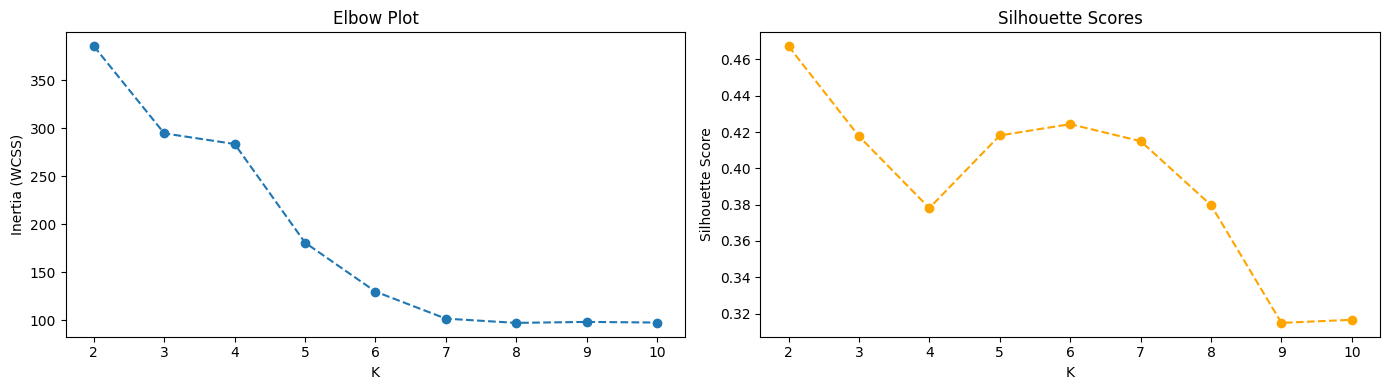

In [12]:
import matplotlib.pyplot as plt

k_values = np.arange(2, 11, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Elbow plot (WCSS)
axes[0].plot(k_values, inertias, linestyle='--', marker='o')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Plot')

# Silhouette score plot
axes[1].plot(k_values, silhouettes, linestyle='--', marker='o', color='orange')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Scores')

plt.tight_layout()
plt.show()

### Identify K values with a cluster of size 3

In [14]:
k_with_size_3_cluster = []

for k in k_values:
    km = KMeans(n_clusters=k, init='random', random_state=9001, n_init=1)
    km.fit(Xs)
    cluster_sizes = np.bincount(km.labels_)
    if 3 in cluster_sizes:
        k_with_size_3_cluster.append(k)

if k_with_size_3_cluster:
    print(f"A cluster of size 3 appears for K values: {k_with_size_3_cluster}")
else:
    print("No cluster of size 3 was found for any K in the range 2-10.")

A cluster of size 3 appears for K values: [np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
